<a href="https://colab.research.google.com/github/HafizRizqi/MachineLearning_2026/blob/main/JS06/JS06_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#💻Lab 2
Klasifikasi SVM dengan Data Dummy Non-Linier

Langkah 1 - Ilustrasi Data Non-Linier

Langkah 1a - Import Library

In [1]:
	# import library
	import numpy as np
	import matplotlib.pyplot as plt
	from scipy import stats
	import seaborn as sns
	from sklearn.svm import SVC

Langkah 1b - Buat Kembali Fungsi Plotting

In [2]:
	# buat sebuah fungsi untuk menampilkan fitting data

	def plot_svc_decision_function(model, ax=None, plot_support=True):

	    if ax is None:
	        ax = plt.gca()
	    xlim = ax.get_xlim()
	    ylim = ax.get_ylim()

	    # buat grid untuk evaluasi model
	    x = np.linspace(xlim[0], xlim[1], 30)
	    y = np.linspace(ylim[0], ylim[1], 30)
	    Y, X = np.meshgrid(y, x)
	    xy = np.vstack([X.ravel(), Y.ravel()]).T
	    P = model.decision_function(xy).reshape(X.shape)

	    # plot batas dan margin
	    ax.contour(X, Y, P, colors='k',
	               levels=[-1, 0, 1], alpha=0.5,
	               linestyles=['--', '-', '--'])

	    # plot support vectors
	    if plot_support:
	        ax.scatter(model.support_vectors_[:, 0],
	                   model.support_vectors_[:, 1],
	                   s=300, linewidth=1, facecolors='none');
	    ax.set_xlim(xlim)
	    ax.set_ylim(ylim)

Langkah 1c - Buat Data Dummy Non-Linier

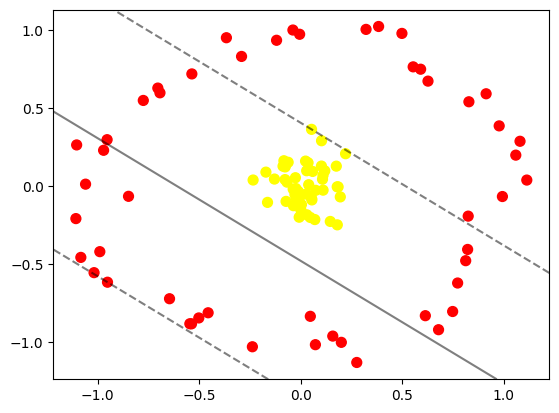

In [3]:
	# contoh data tidak terpisah secara linier
	from sklearn.datasets import make_circles
	X, y = make_circles(100, factor=.1, noise=.1)

	clf = SVC(kernel='linear').fit(X, y)

	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf, plot_support=False);

 tidak ditemukan sebuah garis pemisah linier yang mampu berperan sebagai pemisah data.

 Definisikan fungsi radial dalam kode.

In [4]:
r = np.exp(-(X**2).sum(1))

 proyeksi radial tidak cukup menggunakan model 2D, maka plot visualisasi diubah menjadi model 3D.

In [5]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.3 MB/s eta 0:00:00


In [6]:
	from mpl_toolkits import mplot3d
	from ipywidgets import interact, fixed

	def plot_3D(elev=30, azim=30, X=X, y=y):
	    ax = plt.subplot(projection='3d')
	    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
	    ax.view_init(elev=elev, azim=azim)
	    ax.set_xlabel('x')
	    ax.set_ylabel('y')
	    ax.set_zlabel('r')

	interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
	         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 2.91494649e-02,  9.80215007e-02],
       [-7.74247841e-02,  4.11077376e-02],
       [ 4.69817791e-02, -2.01856405e-01],
       [ 9.13222836e-01,  5.91950678e-01],
       [ 6.13748605e-01, -8.32325634e-01],
       [ 3.21666643e-01,  1.00524410e+00],
       [-1.16204483e-02, -5.92881867e-02],
       [ 5.31583969e-02,  3.63670638e-01],
       [ 2.75959898e-01, -1.13262936e+00],
       [ 4.71015270e-02, -8.36383887e-01],
       [-1.19182059e-01,  9.35354623e-01],
       [-9.52140761e-01, -6.17457608e-01],
       [ 2.36618726e-02,  1.59939892e-01],
       [ 1.79598657e-01, -5.15804241e-03],
       [ 1.99870513e-01, -1.00338493e+00],
       [-2.86738252e-02, -5.46869582e-02],
       [-5.36573749e-01,  7.19435292e-01],
       [-7.69291555e-02,  1.22615317e-01],
       [-8.73454125e-02,  1.27507375e-01],
       [-1.06025885e+00,  1.18328170e-02],
       [ 9.93466747e-01, -6.75289789e-02],
       [-7.04180812e-01,  6.28564383e-01],
       [ 3.00184834e-02, -1.84964812e-01],
       [ 1.02375198e-01,  2.90583846e-01],
       [-6.93716542e-01,  5.98074280e-01],
       [-2.39659868e-02, -1.63370343e-02],
       [-5.38277375e-01, -8.84645389e-01],
       [ 4.98436700e-01,  9.79456769e-01],
       [-2.91724096e-01,  8.31606547e-01],
       [ 8.24895874e-01, -1.93373314e-01],
       [-1.71674939e-01,  8.90648450e-02],
       [ 8.22166045e-01, -4.07140402e-01],
       [ 5.90528216e-01,  7.49633516e-01],
       [ 7.34785926e-02, -2.76819201e-02],
       [-6.76379848e-02,  2.48316763e-02],
       [-4.56386055e-01, -8.13643333e-01],
       [-2.63883656e-02,  5.31895879e-02],
       [ 2.20721822e-01,  2.07305431e-01],
       [-8.30668791e-02,  1.62139085e-01],
       [ 7.21424084e-02, -1.01838247e+00],
       [ 3.83578321e-01,  1.02393034e+00],
       [-5.46433008e-01, -8.84003525e-01],
       [ 5.48584822e-02, -8.92040394e-02],
       [ 1.05942716e+00,  1.98150358e-01],
       [ 9.77591971e-01,  3.85906760e-01],
       [-7.44411167e-02,  1.34767621e-01],
       [-5.02315236e-01, -8.46802830e-01],
       [ 1.94761433e-01, -6.99113162e-02],
       [ 8.12627854e-01, -4.79278266e-01],
       [ 6.78866647e-01, -9.22254562e-01],
       [-3.86440366e-02,  1.00116017e+00],
       [-7.75802676e-01,  5.49200313e-01],
       [-1.01843354e+00, -5.56164560e-01],
       [-2.17339617e-02, -8.23454888e-02],
       [-7.24015258e-02, -9.86980141e-02],
       [ 1.09597283e-01,  6.81773540e-02],
       [-6.46546283e-01, -7.23449204e-01],
       [ 1.79969946e-01, -2.49261100e-01],
       [ 1.09988056e-01, -2.65951165e-02],
       [ 5.33021401e-02, -7.91294885e-02],
       [ 3.91176711e-02,  8.32683429e-03],
       [-9.90002394e-01, -4.21384582e-01],
       [ 3.38504071e-03, -1.19245068e-01],
       [-8.48565199e-01, -6.61870835e-02],
       [-7.75935382e-03, -2.00248956e-01],
       [ 6.26826910e-01,  6.73146399e-01],
       [ 2.63601730e-02, -5.18157255e-02],
       [-1.63696747e-01, -1.05075954e-01],
       [-5.52866328e-03,  9.73932417e-01],
       [-9.71371133e-01,  2.29290154e-01],
       [ 6.34377507e-04, -1.54340595e-01],
       [ 1.07171984e-01,  4.37242986e-02],
       [ 3.59322006e-02,  1.49288092e-01],
       [-1.19842444e-02, -3.52368055e-02],
       [-3.73150764e-02, -2.00914482e-02],
       [-2.10982950e-03, -6.33848671e-02],
       [-6.21870456e-02,  1.52386594e-01],
       [ 1.84029846e-01, -5.63601607e-03],
       [ 1.75123228e-01,  1.27473400e-01],
       [-3.66364575e-01,  9.51726899e-01],
       [ 1.18326497e-01,  9.74944418e-02],
       [-3.59750443e-02, -1.26323045e-01],
       [ 5.53811105e-01,  7.64784766e-01],
       [ 7.72899205e-01, -6.22623265e-01],
       [ 1.01862333e-01,  1.27981422e-01],
       [-1.10788438e+00, -2.09176243e-01],
       [-1.08350945e+00, -4.58162675e-01],
       [-9.54108668e-01,  2.97315038e-01],
       [ 7.48306232e-01, -8.05471366e-01],
       [ 6.92036479e-02, -2.15325209e-01],
       [ 1.08024558e+00,  2.87157355e-01],
       [-2.34765759e-01,  3.84659735e-02

Langkah 2 - Fitting Model


proyeksi titik data sejumlah N ke dalan suatu dimensi N menyebabkan beban komputasi juga bertambah. Untuk mengatasi hal ini, kernel radial basis function (RBF) pada Scikit-Learn digunakan.

In [7]:
	clf = SVC(kernel='rbf', C=1E6)
	clf.fit(X, y)

SVC(C=1000000.0)

Plot hasil decision boundaries dari kernel RBF

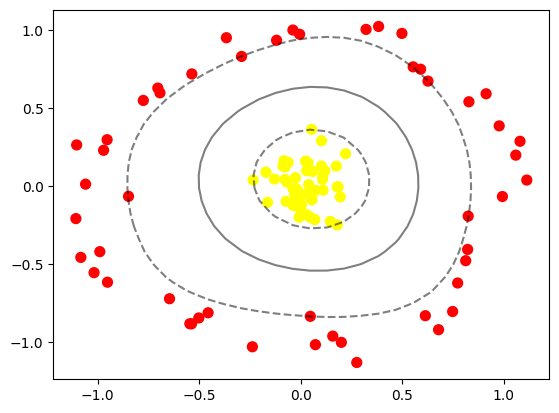

In [8]:
	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf)
	plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
	            s=300, lw=1, facecolors='none')